<a href="https://colab.research.google.com/github/jaydenjung-bohs09/jaydenjung-bohs09.github.io/blob/main/DeepPurpose_DTI_Inference_and_Training_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=darkblue> **DeepPurpose for Drug–Target Interaction Prediction** </font>

Welcome! This notebook is a gentle introduction to **drug–target interaction (DTI)** prediction using **DeepPurpose** ([Huang et al., *Bioinformatics* 2020](https://academic.oup.com/bioinformatics/article/36/22-23/5545/6020256)).

The question we're asking is easy to state: given a small molecule (written as a SMILES string) and a protein (written as its amino-acid sequence), how strongly do they bind? DeepPurpose answers this with a library of deep learning models that read the two inputs and predicts a binding-affinity score.

DeepPurpose supports training of customized DTI prediction models by implementing 15 compound and protein encoders and over 50 neural architectures, along with providing many other useful features.

We'll work in two parts. First we load a pretrained model and use it for inference. Then we train our own model from scratch on the PBC2.0 dataset, so you can see the whole pipeline end to end.

**How to run.** The pretrained models are small and can run comfortably on CPU. For training, you will need a GPU for speed-ups. You may change runtime type by:

`Runtime` / A `🔽` dropdown menu in the upper right corner  → `Change runtime type` → `T4 GPU`.

> <font color=red> **Please be mindful of your team's total compute units and arrange to use them strategically.** In the worst case when everyone in your team has hit compute limit on Colab and couldn't make any progress on the project, please contact the TAs and we will help you figure out some solutions. </font>

## <font color=darkblue> **1. Install** </font>

First we download the DeepPurpose source code and install the few extra libraries it needs. Colab already includes the large ones (`torch`, `numpy`, `pandas`, `scikit-learn`, `scipy`, `matplotlib`, and `tqdm`), so we install only the lightweight extras.

> Note: We intentionally skip the heavy graph libraries (`dgl`, `dgllife`, `ax-platform`) that a full `pip install DeepPurpose` would add, since we won't use the graph-based encoders here and they take a while to set up. But if you will run the graph-based models as baselines, you may need to install more dependencies.

In [ ]:
# Takes about 1-2 minutes: clone the source and install the minimal dependencies.
!git clone -q https://github.com/kexinhuang12345/DeepPurpose.git
!pip install -q rdkit subword-nmt lifelines prettytable pandas-flavor wget descriptastorus

import sys
sys.path.append('/content/DeepPurpose')
print('done')

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 12.6 MB/s eta 0:00:00
done


## <font color=darkblue> **2. Load a pretrained model** </font>

The function `model_pretrained(model=NAME)` downloads the trained weights from the Harvard Dataverse and rebuilds the network for you. We'll start with **`MPNN_CNN_BindingDB`**, which pairs a Message-Passing Neural Network for the drug with a CNN for the protein, trained on BindingDB Kd measurements.

If you'd like to try a different pretrained model, just change the name below. Here are some ready-to-use options for small-molecule and protein pairs:

| Model name | Drug encoder | Protein encoder | Trained on |
|---|---|---|---|
| `MPNN_CNN_BindingDB` | MPNN | CNN | BindingDB (Kd) |
| `CNN_CNN_BindingDB` | CNN | CNN | BindingDB (Kd) |
| `Morgan_CNN_BindingDB` | Morgan fingerprint | CNN | BindingDB (Kd) |
| `MPNN_CNN_DAVIS` | MPNN | CNN | DAVIS |
| `MPNN_CNN_KIBA` | MPNN | CNN | KIBA |
| `Transformer_CNN_BindingDB` | Transformer | CNN | BindingDB (Kd) |

One thing to keep in mind about the scores: the BindingDB and DAVIS models are trained on a log scale (similar to pKd or pIC50), so a higher score means stronger predicted binding. If you'd rather read the output as a Kd concentration in nM, set `convert_y=True` in the calls below, and remember that on that scale a lower number means stronger binding.

> <font color=red> Note: Be aware that these pretrained models were **trained on different datasets** than the one we are using for Project 1 (PBCNet2.0). For rigorous comparison of architecture baselines against your final model, you will need to **retrain these model** from scratch on our data. </font>

In [ ]:
from DeepPurpose import DTI as models

MODEL_NAME = 'MPNN_CNN_BindingDB'
net = models.model_pretrained(model=MODEL_NAME)
print('Loaded', MODEL_NAME, '| binary classifier:', net.binary)

pretrained model Successfully Downloaded...
Loaded MPNN_CNN_BindingDB | binary classifier: False


## <font color=darkblue> **3. Inference: score drug and target pairs** </font>

Now let's use the model. Edit the `drug_smiles`, `targets`, and the name lists below with your own inputs. The `virtual_screening` function scores each (drug, target) pair row by row, prints a ranked table, and also returns the scores as a list so you can use them in code.

In [ ]:
# Your inputs, paired row by row.
drug_smiles = [
    'CC(=O)OC1=CC=CC=C1C(=O)O',          # Aspirin
    'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',      # Caffeine
]
drug_names = ['Aspirin', 'Caffeine']

# COX-1 (UniProt P23219) amino-acid sequence, paired with each drug above.
cox1 = ('MSRSLLLWFLLFLLLLPPLPVLLADPGAPTPVNPCCYYPCQHQGICVRFGLDRYQCDCTRTGYSGPNCTIPGLWTWL'
        'RNSLRPSPSFTHFLLTHGRWFWEFVNATFIREMLMRLVLTVRSNLIPSPPTYNSAHDYISWESFSNVSYYTRILPSV')
targets = [cox1, cox1]
target_names = ['COX-1', 'COX-1']

scores = models.virtual_screening(
    drug_smiles, targets, net,
    drug_names=drug_names, target_names=target_names,
    convert_y=False,   # set True to read the output as Kd in nM instead of the log-scale score
)
scores

virtual screening...
Drug Target Interaction Prediction Mode...
in total: 2 drug-target pairs
encoding drug...
unique drugs: 2
encoding protein...
unique target sequence: 1
Done.
predicting...
---------------
Virtual Screening Result
+------+-----------+-------------+---------------+
| Rank | Drug Name | Target Name | Binding Score |
+------+-----------+-------------+---------------+
|  1   |  Aspirin  |    COX-1    |      3.70     |
|  2   |  Caffeine |    COX-1    |      2.22     |
+------+-----------+-------------+---------------+


[3.7010812759399414, 2.2203493118286133]

## <font color=darkblue> **4. Repurposing: one target against many molecules** </font>

Sometimes you have a single protein in mind and a whole list of candidate molecules, and you want to know which ones are most likely to bind. That is what `repurpose` is for: it scores every molecule against one target and ranks them for you.

In [ ]:
library_smiles = [
    'CC(=O)OC1=CC=CC=C1C(=O)O',                       # Aspirin
    'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O',                  # Ibuprofen
    'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',                   # Caffeine
    'CC1=CC=C(C=C1)C(=O)C1=CC=C(C=C1)CC(=O)O',        # an example molecule
]
library_names = ['Aspirin', 'Ibuprofen', 'Caffeine', 'Compound-4']

ranked = models.repurpose(
    library_smiles, cox1, net,
    drug_names=library_names, target_name='COX-1',
    convert_y=False,
)
ranked

repurposing...
Drug Target Interaction Prediction Mode...
in total: 4 drug-target pairs
encoding drug...
unique drugs: 4
encoding protein...
unique target sequence: 1
Done.
predicting...
---------------
Drug Repurposing Result for COX-1
+------+------------+-------------+---------------+
| Rank | Drug Name  | Target Name | Binding Score |
+------+------------+-------------+---------------+
|  1   | Compound-4 |    COX-1    |      5.85     |
|  2   |  Aspirin   |    COX-1    |      3.70     |
|  3   |  Caffeine  |    COX-1    |      2.95     |
|  4   | Ibuprofen  |    COX-1    |      2.11     |
+------+------------+-------------+---------------+

[3.701080799102783, 2.1065101623535156, 2.949498414993286, 5.848255634307861]

## <font color=darkblue> **5. Train your own model on the PBCNet dataset** </font>

So far we've only used weights that someone else trained. Now let's build and train a DTI model ourselves, using DeepPurpose's own building blocks, on the PBCNet2.0 dataset for Project 1. The pipeline has five short steps:

1. Mount Google Drive and load your dataset of (drug, target, affinity) rows.
2. Choose a drug encoder and a protein encoder.
3. Turn the raw strings into model inputs, keeping the file's own train, validation, and test split.
4. Create a configuration and initialize a fresh, untrained model.
5. Train, and let DeepPurpose report the metrics.

The dataset file we provided already has a `split` column, so we respect it rather than making a new random split. Two small preprocessing steps happen here too: we uppercase the protein sequences (DeepPurpose's encoders expect standard uppercase amino-acid codes), and we convert the affinity to the same log scale the pretrained models use (`9 - log10(nM)`, so higher means stronger binding).

For a quick classroom run we subsample the data. Set `SUBSAMPLE_ROWS = None` to train on the full dataset instead (much slower).

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from DeepPurpose import utils
import os, pandas as pd, numpy as np

# --- paths (edit if your files live elsewhere) ---
DATA_TSV       = '/content/drive/MyDrive/dti/pbcnet2_bindingdb_combined_uniprot_with_splits.tsv'
DRIVE_SAVE_DIR = '/content/drive/MyDrive/dti/deeppurpose_models'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

# Total rows for a quick demo (drawn 80/10/10 from the file's own splits). None = full dataset.
SUBSAMPLE_ROWS = 20000

# Step 1: load and clean the dataset.
df = pd.read_csv(DATA_TSV, sep='\t')
df.columns = ['smiles', 'seq', 'aff', 'assay', 'uniprot', 'family accession', 'family','split']   # rename column names for simplicity

df['seq'] = df['seq'].astype(str).str.upper().str.strip()      # DeepPurpose expects uppercase sequences
df['aff'] = pd.to_numeric(df['aff'], errors='coerce')
df = df.dropna(subset=['smiles', 'seq', 'aff'])
df = df[df['aff'] > 0]
df['y'] = 9.0 - np.log10(df['aff'].values)                     # nM -> log (p) scale

for col in ['family accession', 'family']:                     # cleaning, keep only the first entry in the family columns
    df[col] = df[col].str.split(';', n=1).str[0].str.strip()

df['split'] = df['split'].replace({'val': 'valid'})            # use the file's own split

if SUBSAMPLE_ROWS:
    frac = {'train': 0.8, 'valid': 0.1, 'test': 0.1}
    df = pd.concat([df[df.split == sp].sample(min((df.split == sp).sum(),
                     int(round(SUBSAMPLE_ROWS * fr))), random_state=0) for sp, fr in frac.items()])

# Step 2: choose the encoders. 'CNN','CNN' trains quickly and is a good first run.
# Switch to 'MPNN','CNN' to mirror the pretrained MPNN_CNN model from earlier (more accurate, but slower).
drug_encoding, target_encoding = 'CNN', 'CNN'

# Step 3: featurize each split separately with 'no_split' so the file's own split is preserved.
def process_split(name):
    g = df[df.split == name]
    return utils.data_process(g.smiles.values, g.seq.values, g.y.values,
                              drug_encoding, target_encoding, split_method='no_split')

train, val, test = process_split('train'), process_split('valid'), process_split('test')
print(len(train), 'train /', len(val), 'valid /', len(test), 'test pairs')

Mounted at /content/drive
Drug Target Interaction Prediction Mode...
in total: 16000 drug-target pairs
encoding drug...
unique drugs: 15815
encoding protein...
unique target sequence: 1201
splitting dataset...
do not do train/test split on the data for already splitted data
Drug Target Interaction Prediction Mode...
in total: 2000 drug-target pairs
encoding drug...
unique drugs: 1992
encoding protein...
unique target sequence: 492
splitting dataset...
do not do train/test split on the data for already splitted data
Drug Target Interaction Prediction Mode...
in total: 2000 drug-target pairs
encoding drug...
unique drugs: 1990
encoding protein...
unique target sequence: 414
splitting dataset...
do not do train/test split on the data for already splitted data
16000 train / 2000 valid / 2000 test pairs


### <font color=darkblue> **Configure and train** </font>

`generate_config` collects all the model and training settings into one dictionary. A few of them are worth knowing:

- `cls_hidden_dims` sets the sizes of the MLP layers that sit on top of the two encoders.
- `train_epoch` is how many passes we make over the training set. We keep it small here so the demo finishes quickly; raise it for better results.
- `LR` is the learning rate, and `batch_size` is how many pairs the model sees per update.

`model_initialize` then builds a fresh model with random weights, and `model.train` runs the training loop. As it trains, DeepPurpose prints the loss each epoch, reports the test metrics at the end, and saves loss-curve figures into the `./result` folder.

Let's use 1 GPU!
--- Data Preparation ---
--- Go for Training ---
Training at Epoch 1 iteration 0 with loss 49.9549. Total time 0.00027 hours
Training at Epoch 1 iteration 100 with loss 1.69015. Total time 0.01027 hours
Validation at Epoch 1 with loss:1.61667, MSE: 1.92999 , Pearson Correlation: 0.32709 with p-value: 4.36E-51 , Concordance Index: 0.60754
Training at Epoch 2 iteration 0 with loss 2.32971. Total time 0.01416 hours
Training at Epoch 2 iteration 100 with loss 1.74034. Total time 0.02444 hours
Validation at Epoch 2 with loss:1.55758, MSE: 1.82545 , Pearson Correlation: 0.35455 with p-value: 2.59E-60 , Concordance Index: 0.61662
Training at Epoch 3 iteration 0 with loss 2.03101. Total time 0.02861 hours
Training at Epoch 3 iteration 100 with loss 1.33863. Total time 0.03861 hours
Validation at Epoch 3 with loss:1.62222, MSE: 1.70469 , Pearson Correlation: 0.41041 with p-value: 4.06E-82 , Concordance Index: 0.64339
Training at Epoch 4 iteration 0 with loss 1.52749. Total time

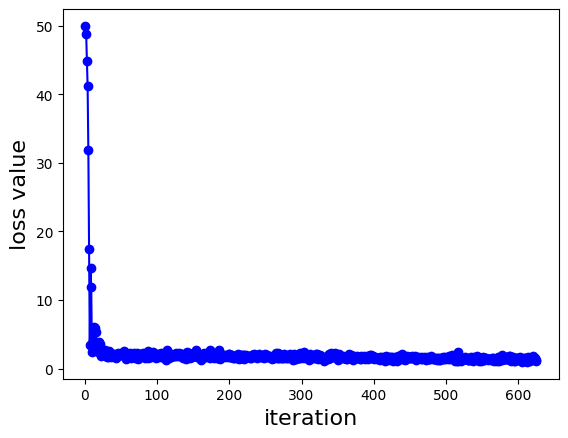

In [ ]:
# Step 4: build the configuration and initialize a fresh (randomly-initialized) model.
config = utils.generate_config(
    drug_encoding, target_encoding,
    cls_hidden_dims=[1024, 512],
    train_epoch=5,  # small epochs for a quick demo, scale up as you move to full dataset
    LR=1e-3,
    batch_size=128,
)
model = models.model_initialize(**config)

# Step 5: train. This is the model learning from scratch on the DAVIS pairs.
model.train(train, val, test)

### <font color=darkblue> **Validation curve** </font>

While `model.train` runs, DeepPurpose records the validation metrics after every epoch and writes them to a small table file inside its results folder. We can read that file back and plot how the validation MSE and Pearson correlation change over the epochs.

A good run shows the MSE going down and the Pearson going up before they level off. If MSE starts climbing again while training loss keeps falling, that is a sign of **overfitting**.

(The curve has one point per epoch, so increase `train_epoch` in the config above if you want a longer, smoother curve.)

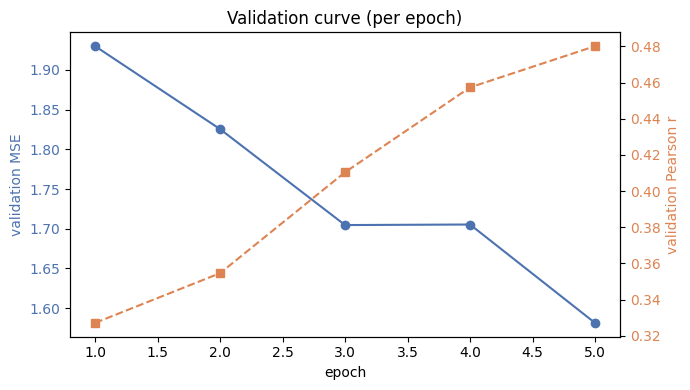

In [ ]:
import matplotlib.pyplot as plt

# DeepPurpose writes per-epoch validation metrics here during training.
table_path = os.path.join(model.result_folder, 'valid_markdowntable.txt')

rows = []
with open(table_path) as f:
    for line in f:
        s = line.strip()
        if s.startswith('|'):                       # keep only the table's data rows
            rows.append([c.strip() for c in s.strip('|').split('|')])

# rows[0] is the header: ['# epoch', 'MSE', 'Pearson Correlation', 'with p-value', 'Concordance Index']
data    = rows[1:]
epochs  = list(range(1, len(data) + 1))
mse     = [float(r[1]) for r in data]
pearson = [float(r[2]) for r in data]

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(epochs, mse, 'o-', color='#4C72B0')
ax1.set_xlabel('epoch')
ax1.set_ylabel('validation MSE', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(epochs, pearson, 's--', color='#DD8452')
ax2.set_ylabel('validation Pearson r', color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')

ax1.set_title('Validation curve (per epoch)')
fig.tight_layout()
plt.show()

### <font color=darkblue> **Save and use the model you trained** </font>

We save the trained model straight to Google Drive, so it stays available after this Colab session ends. It behaves exactly like the pretrained `net` from earlier: you can reload it later with `models.model_pretrained(path=...)`, and score new pairs with the same `virtual_screening` and `repurpose` functions. Below we reuse the drug and target inputs from Section 3, but pass in your freshly trained model.

In [ ]:
# Save the trained model to Google Drive so it persists across sessions.
save_path = os.path.join(DRIVE_SAVE_DIR, f'pbcnet_{drug_encoding}_{target_encoding}')
model.save_model(save_path)
print('model saved to', save_path)
# Reload it later with:  model = models.model_pretrained(path=save_path)

# Use it just like the pretrained model, reusing the inputs from Section 3.
_ = models.virtual_screening(
    drug_smiles, targets, model,
    drug_names=drug_names, target_names=target_names,
    convert_y=False,
)

model saved to /content/drive/MyDrive/dti/deeppurpose_models/pbcnet_CNN_CNN
virtual screening...
Drug Target Interaction Prediction Mode...
in total: 2 drug-target pairs
encoding drug...
unique drugs: 2
encoding protein...
unique target sequence: 1
Done.
predicting...
---------------
Virtual Screening Result
+------+-----------+-------------+---------------+
| Rank | Drug Name | Target Name | Binding Score |
+------+-----------+-------------+---------------+
|  1   |  Aspirin  |    COX-1    |      5.37     |
|  2   |  Caffeine |    COX-1    |      5.31     |
+------+-----------+-------------+---------------+


## <font color=darkblue> **A few things worth knowing** </font>

- **Reading the scores.** For the log-scale BindingDB, DAVIS, and KIBA models, a higher score means stronger predicted binding. If you set `convert_y=True`, the score becomes an estimated Kd in nM, and on that scale a lower value means stronger binding.
- **Classification vs. regression.** Some models are binary classifiers and return an interaction probability between 0 and 1 instead of an affinity. You can check which kind you have with `net.binary` (or `model.binary`).
- **Trying other encoders.** In Section 5 you can change `drug_encoding` and `target_encoding` to any of DeepPurpose's options (for example `Morgan`, `MPNN`, or `Transformer` for drugs, and `AAC`, `CNN`, or `Transformer` for proteins) and retrain to compare.
- **Where the results go.** The ranked inference tables are saved to `./result/virtual_screening.txt` and `./result/repurposing.txt`, and training curves are saved in `./result`.
- **More models and documentation:** https://github.com/kexinhuang12345/DeepPurpose#pretrained-models